# Tech Challenge

# 1 - Entendimento do Negócio

## Síndrome do Ovário Policístico (SOP)

A SOP é um distúrbio endócrino e metabólico comum, afetando 4-20% das mulheres em idade fértil, caracterizado por desequilíbrio hormonal com altos níveis de andrógenos, interferindo na ovulação.

### Principais Características e Sintomas
- **Ciclos menstruais irregulares**: Menstruação pouco frequente ou ausente (anovulação).
- **Hiperandrogenismo**: Aumento de pelos (hirsutismo), acne e pele oleosa.
- **Ovários policísticos**: Vários pequenos cistos detectados por ultrassom.
- **Problemas metabólicos**: Resistência à insulina, ganho de peso e risco aumentado de diabetes tipo 2.
- **Infertilidade**: Causa comum de infertilidade feminina devido à falta de ovulação.

### Diagnóstico e Tratamento
- **Diagnóstico**: Baseado nos critérios de Rotterdam (oligo-anovulação, hiperandrogenismo e morfologia ovariana policística).
- **Tratamento**: Não curável, mas manejável com mudanças no estilo de vida (dieta e exercício), anticoncepcionais para regular o ciclo, metformina para resistência à insulina e medicamentos para induzir ovulação.
- **Riscos a longo prazo**: Aumento de doenças cardiovasculares e câncer de endométrio sem tratamento.

### Diferença Importante
Ter ovários com aspecto policístico no ultrassom não equivale à SOP. A síndrome envolve um desequilíbrio metabólico-hormonal, enquanto os cistos podem existir isoladamente.



*Texto redigido com auxílio de IA*


## Importação dos dados

Vamos usar como base de dados para nosso modelo o arquivo PCOS_data_without_infertility.csv. 

<blockquote>
  <p>Disponibilizado em: [Kaggle](https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos)</p>
  <p>Autor: Prasoon Kottarathil</p>
  <p>Title: Polycystic ovary syndrome (PCOS)</p>
  <p>Year: 2020</p>
  <p>Publisher: kaggle</p>
  <p>Journal: Kaggle Dataset</p>

  <p>Usability</p>
  <p>9.12</p>

  <p>License</p>
  <p>CC BY-NC-SA 4.0</p>
</blockquote>

Nota: Para facilitar o entendimento, os nomes das colunas foram traduzidos.

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA


In [201]:
dados = pd.read_csv('PCOS_data_without_infertility.csv', delimiter=';')

In [202]:
dados.info()
dados.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 44 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Numero Sequencial                              541 non-null    int64  
 1   Numero Arquivo Paciente                        541 non-null    int64  
 2   SOP (S/N)                                      541 non-null    int64  
 3   Idade                                          541 non-null    int64  
 4   Peso (Kg)                                      541 non-null    float64
 5   Altura (cm)                                    541 non-null    float64
 6   IMC                                            541 non-null    float64
 7   Grupo Sanguineo                                541 non-null    int64  
 8   Frequencia Cardiaca (bpm)                      541 non-null    int64  
 9   Frequencia Respiratoria (breaths/min)          541 non

,Numero Sequencial,Numero Arquivo Paciente,SOP (S/N),Idade,Peso (Kg),Altura (cm),IMC,Grupo Sanguineo,Frequencia Cardiaca (bpm),Frequencia Respiratoria (breaths/min),...,Espinhas (S/N),Fast food (S/N),Exercita Regularmente (S/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Numero Foliculos (Ovario Esquerdo),Numero Foliculos (Ovario Direito),Media Tamanho Foliculo (Ovario Esquerdo) (mm),Media Tamanho Foliculo (Ovario Direito) (mm),Espessura do endometrio (mm)
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


# 2 - Entendimento dos dados


## Descrição das Colunas

Abaixo, descrições breves de cada coluna do dataset, focando em valores de referência ideais para mulheres e indicadores de problemas de saúde. Descrições baseadas em fontes médicas como WHO, NIH e literatura especializada.

- **Numero Sequencial**: Identificador único da paciente (sem valor clínico).
- **Numero Arquivo Paciente**: Número do arquivo da paciente (sem valor clínico).
- **SOP (S/N)**: Indicador binário se a paciente tem SOP (S=Sim, N=Não).
- **Idade**: Idade em anos. Ideal: 18-35 anos para fertilidade; >40 pode indicar reserva ovariana baixa (fonte: WHO).
- **Peso (Kg)**: Peso corporal (usado para calcular IMC).
- **Altura (cm)**: Altura em centímetros (usado para calcular IMC).
- **IMC**: Índice de Massa Corporal. Ideal: 18.5-24.9; >25 sobrepeso, >30 obesidade, associado a SOP (fonte: WHO).
- **Grupo Sanguineo**: Tipo sanguíneo (A+ = 11 / A- = 12 / B+ = 13 / B- = 14 / O+ =15 / O- = 16 / AB+ =17 / AB- = 18)
- **Frequencia Cardiaca (bpm)**: Batimentos por minuto em repouso. Ideal: 60-100 bpm; >100 taquicardia, possível hipertensão (fonte: AHA).
- **Frequencia Respiratoria (breaths/min)**: Respirações por minuto. Ideal: 12-20; >20 pode indicar ansiedade ou problemas respiratórios (fonte: NIH).
- **Hemoglobina (g/dl)**: Nível de hemoglobina. Ideal: 12-15.5 g/dl; <12 anemia, >16 policitemia (fonte: WHO).
- **Ciclo (Regular /Irregular)**: Regularidade do ciclo menstrual. Irregular indica possível SOP ou anovulação (fonte: ACOG).
- **Duracao Ciclo (days)**: Duração do ciclo em dias. Ideal: 21-35 dias; <21 ou >35 irregularidade (fonte: NIH).
- **Duracao Casamento (Anos)**: Anos de casamento.
- **Gravida (S/N)**: Se já engravidou (S=Sim, N=Não).
- **Numero de abortos**: Número de abortos. >1 pode indicar problemas hormonais (fonte: WHO).
- **I   beta-HCG(mIU/mL)**: Beta-HCG inicial. Ideal: <5 mIU/mL (não grávida); >25 confirma gravidez (fonte: ACOG).
- **II  beta-HCG(mIU/mL)**: Beta-HCG secundário. Similar ao acima.
- **FSH(mIU/mL)**: Hormônio Folículo-Estimulante. Ideal: 3-10 mIU/mL (fase folicular); >15 baixa reserva ovariana (fonte: ASRM).
- **LH(mIU/mL)**: Hormônio Luteinizante. Ideal: 1.8-12.5 mIU/mL (folicular); >10 pode indicar SOP (fonte: ASRM).
- **FSH/LH**: Razão FSH/LH. Ideal: <2; >2-3 pode indicar SOP (fonte: literatura PCOS).
- **Medida Quadril (polegadas)**: Circunferência do quadril (usado para relação cintura-quadril).
- **Medida Cintura (polegadas)**: Circunferência da cintura. Ideal: <35 polegadas; >35 risco de síndrome metabólica (fonte: NIH).
- **Relacao Cintura Quadril**: Razão cintura/quadril. Ideal: <0.85; >0.85 risco cardiovascular (fonte: WHO).
- **TSH (mIU/L)**: Hormônio Tireoestimulante. Ideal: 0.4-4.0 mIU/L; >4.5 hipotireoidismo, <0.4 hipertireoidismo (fonte: ATA).
- **AMH(ng/mL)**: Hormônio Antimülleriano. Ideal: 1.0-3.0 ng/mL; <1 baixa reserva, >3.5 possível SOP (fonte: ASRM).
- **PRL(ng/mL)**: Prolactina. Ideal: <25 ng/mL; >25 hiperprolactinemia, possível tumor hipofisário (fonte: NIH).
- **Vit D3 (ng/mL)**: Vitamina D3. Ideal: 30-50 ng/mL; <20 deficiência, associada a SOP (fonte: Endocrine Society).
- **PRG(ng/mL)**: Progesterona. Ideal: 0.5-20 ng/mL (folicular); <0.5 anovulação (fonte: ASRM).
- **RBS(mg/dl)**: Glicemia em jejum. Ideal: <100 mg/dl; 100-125 pré-diabetes, >126 diabetes (fonte: ADA).
- **Ganho Peso (S/N)**: Se houve ganho de peso recente (S=Sim, N=Não).
- **Crescimento Capilar (s/n)**: Crescimento excessivo de pelos (s=sim, n=não) - sinal de hiperandrogenismo.
- **Escurecimento da pele (S/N)**: Acantose nigricans (S=Sim, N=Não) - sinal de resistência à insulina.
- **Perda de Cabelo (S/N)**: Alopecia (S=Sim, N=Não) - sinal de hiperandrogenismo.
- **Espinhas (S/N)**: Acne (S=Sim, N=Não) - sinal de hiperandrogenismo.
- **Fast food (S/N)**: Consumo frequente de fast food (S=Sim, N=Não) - fator de risco para obesidade.
- **Exercita Regularmente (S/N)**: Prática regular de exercício (S=Sim, N=Não) - protetor contra SOP.
- **BP _Systolic (mmHg)**: Pressão arterial sistólica. Ideal: <120 mmHg; >130 hipertensão (fonte: AHA).
- **BP _Diastolic (mmHg)**: Pressão arterial diastólica. Ideal: <80 mmHg; >80 hipertensão (fonte: AHA).
- **Numero Foliculos (Ovario Esquerdo)**: Número de folículos no ovário esquerdo. Ideal: 5-13; >12 possível SOP (fonte: Rotterdam criteria).
- **Numero Foliculos (Ovario Direito)**: Número de folículos no ovário direito. Similar ao esquerdo.
- **Media Tamanho Foliculo (Ovario Esquerdo) (mm)**: Tamanho médio dos folículos. Ideal: 2-10 mm.
- **Media Tamanho Foliculo (Ovario Direito) (mm)**: Similar ao esquerdo.
- **Espessura do endometrio (mm)**: Espessura endometrial. Ideal: 6-10 mm (fase proliferativa); >12 possível hiperplasia (fonte: ACOG).

*Texto redigido com auxílio de IA*

# 3 - Preparação dos dados



## 3.1 - Podemos identificar algumas anomalias na base de dados.


Visto que os nomes das colunas possuem espaços no começo ou final do texto, vamos remover esses espaços e excluir da base de dados colunas irrelevantes como Número sequencial e Número do Arquivo Paciente.


A base possui 44 colunas e 541 linhas.

- As colunas **Número Sequencial** e **Numero Arquivo Paciente** possuem dados para controle, sem valor analítico.
- As colunas **Duração Casamento (Anos)** e *Fast food (S/N)* possuem 1 registro nulo
- A coluna **AMH(ng/mL)** Está com o tipo object, mas olhando os dados podemos perceber que deveria ser uma coluna numérica. Logo, possui algum registro inconforme.
- Algumas colunas possuem espaços no começo ou no final do nome.

In [ ]:
# Removendo espaços em branco dos nomes das colunas
dados.columns = dados.columns.str.strip()

# Removendo colunas irrelevantes
colunas_irrelevantes = ['Numero Sequencial', 'Numero Arquivo Paciente']
dados = dados.drop(columns=colunas_irrelevantes)

# Obtenção de registros com valores nulos
dados['AMH(ng/mL)'] = pd.to_numeric(dados['AMH(ng/mL)'], errors='coerce')
dados_com_registros_vazios = dados[dados.isnull().any(axis=1)].head()
dados_com_registros_vazios.isnull().sum()

# Tratamento de valores nulos 'Duracao Casamento (Anos)'
median = dados['Duracao Casamento (Anos)'].median()
dados_com_registros_vazios['Duracao Casamento (Anos)'] = dados_com_registros_vazios['Duracao Casamento (Anos)'].fillna(median)

# Tratamento de valores inconformes em 'AMH(ng/mL)'
median = dados['AMH(ng/mL)'].median()
dados_com_registros_vazios['AMH(ng/mL)'] = dados_com_registros_vazios['AMH(ng/mL)'].fillna(median)

# Tratamento de valores nulos 'Fast food (S/N)' para substituir por valor mais recorrente
valor_mais_recorrente = dados['Fast food (S/N)'].value_counts().sort_values(ascending=False).index[0]
dados_com_registros_vazios['Fast food (S/N)'] = dados_com_registros_vazios['Fast food (S/N)'].fillna(valor_mais_recorrente)

# Ajustando base original com os registros tratados
dados.loc[dados_com_registros_vazios.index.values] = dados_com_registros_vazios
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 42 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   SOP (S/N)                                      541 non-null    int64  
 1   Idade                                          541 non-null    int64  
 2   Peso (Kg)                                      541 non-null    float64
 3   Altura (cm)                                    541 non-null    float64
 4   IMC                                            541 non-null    float64
 5   Grupo Sanguineo                                541 non-null    int64  
 6   Frequencia Cardiaca (bpm)                      541 non-null    int64  
 7   Frequencia Respiratoria (breaths/min)          541 non-null    int64  
 8   Hemoglobina (g/dl)                             541 non-null    float64
 9   Ciclo (Regular /Irregular)                     541 non

## 3.2 - Distribuição dos dados

Agora, podemos notar que a base não possui mais valores nulos e todas as colunas são númericas.

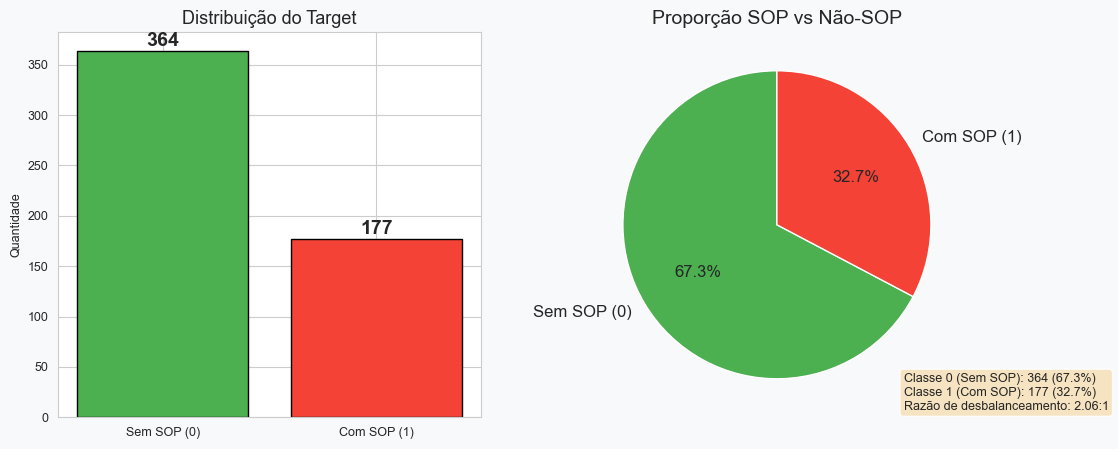

In [204]:
# Distribuição do target

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Contagem
target = 'SOP (S/N)'
target_counts = dados[target].value_counts()

labels = ['Sem SOP (0)', 'Com SOP (1)']
cores = ['#4CAF50', '#F44336']

axes[0].bar(labels, target_counts.values, color=cores, edgecolor='black')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=14)
axes[0].set_title('Distribuição do Target', fontsize=13)
axes[0].set_ylabel('Quantidade')

# Percentual
axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=cores, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporção SOP vs Não-SOP', fontsize=14)

textstr = f'Classe 0 (Sem SOP): {target_counts[0]} ({target_counts[0]/len(dados[target])*100:.1f}%)'
textstr += f'\nClasse 1 (Com SOP): {target_counts[1]} ({target_counts[1]/len(dados[target])*100:.1f}%)'
textstr += f'\nRazão de desbalanceamento: {target_counts[0]/target_counts[1]:.2f}:1'

axes[0].text(2.00, 0.02, textstr, transform=axes[0].transAxes,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.show()

In [205]:

colunas_categoricas_list = [
    'Ciclo (Regular /Irregular)',
    'Gravida (S/N)',
    'Ganho Peso (S/N)',
    'Crescimento Capilar (s/n)',
    'Escurecimento da pele (S/N)',
    'Perda de Cabelo (S/N)',
    'Espinhas (S/N)',
    'Fast food (S/N)',
    'Exercita Regularmente (S/N)'
]


X = dados.drop(columns=[target])
y = dados[target]

X_sem_categoricas = X.drop(columns=colunas_categoricas_list)

Colunas categóricas encontradas: 9


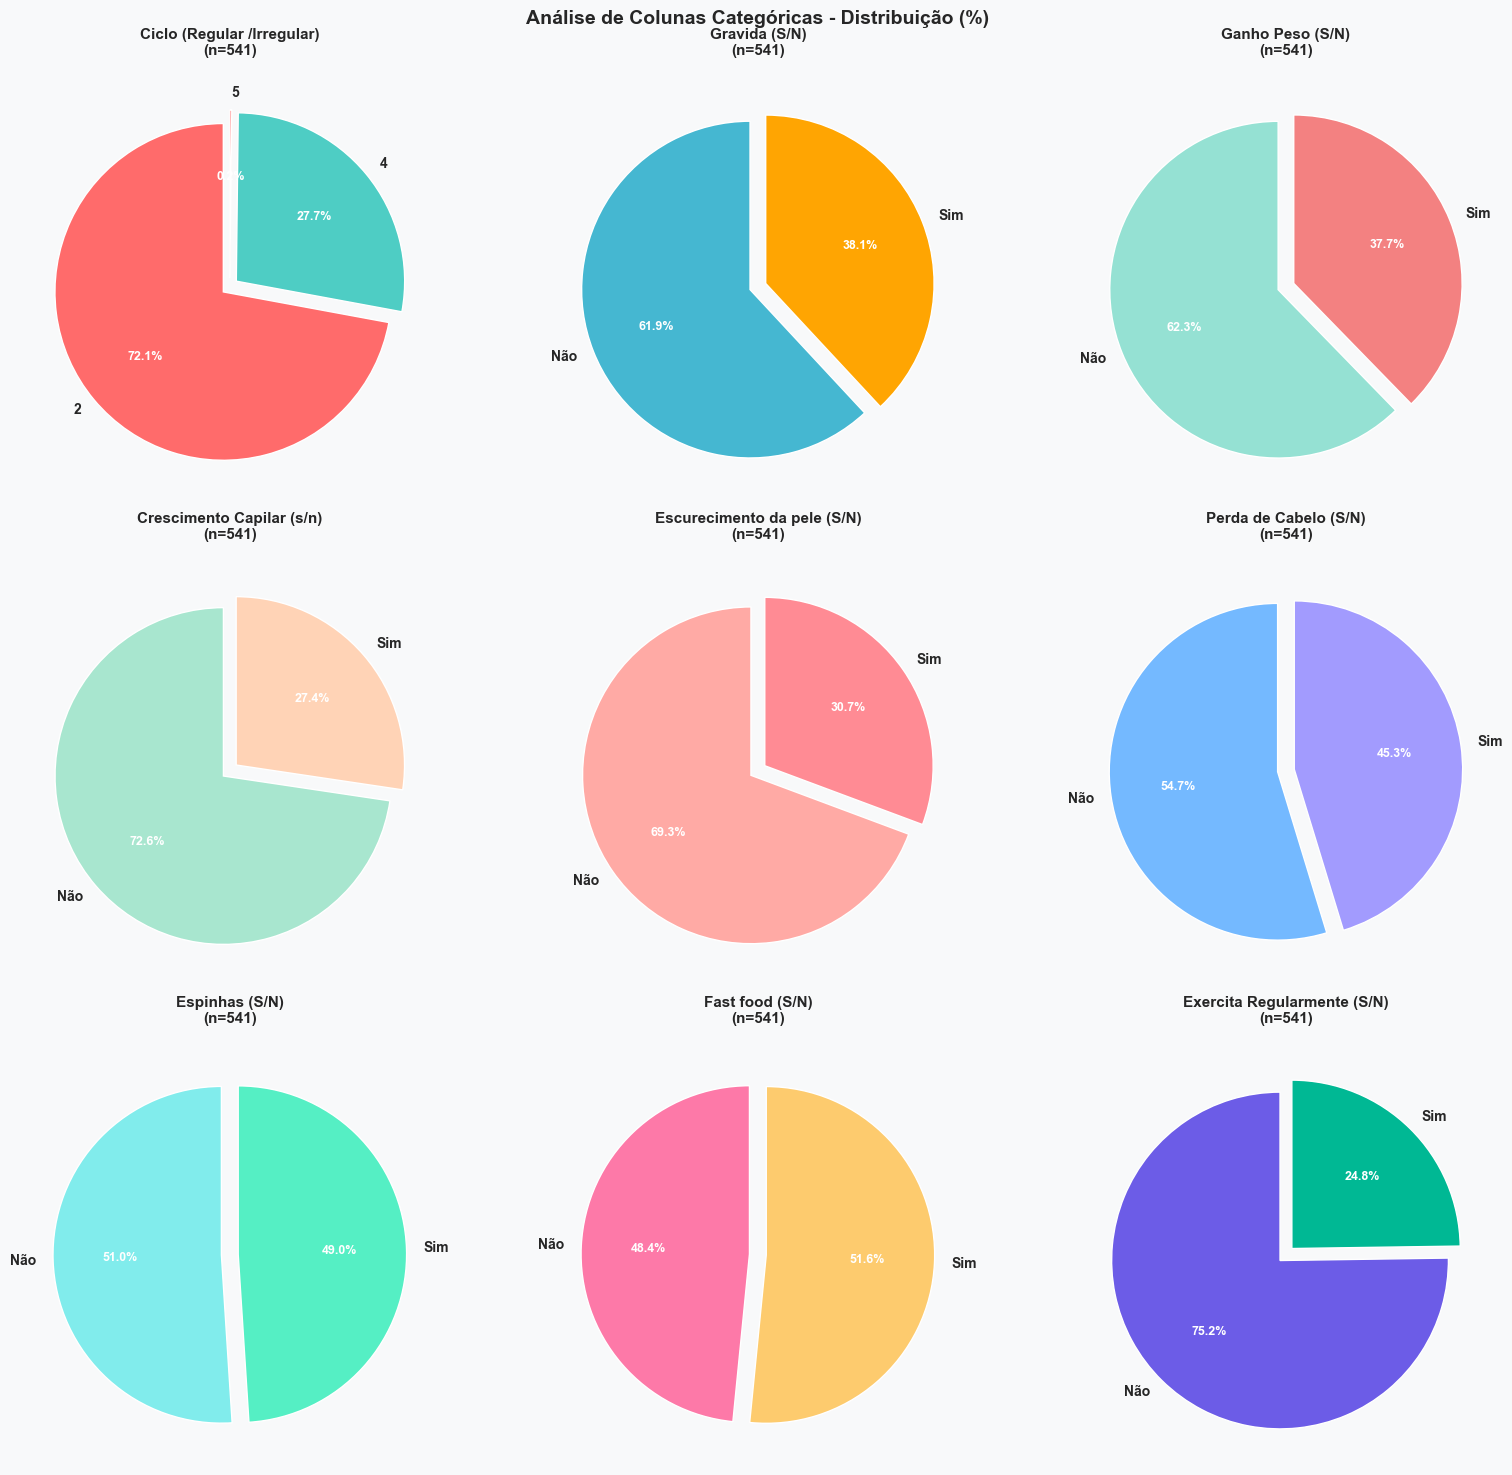

In [206]:
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['font.size'] = 10

colunas_cat = [col for col in colunas_categoricas_list if col in dados.columns]

print(f"Colunas categóricas encontradas: {len(colunas_cat)}")

if len(colunas_cat) > 0:
    n_cat = len(colunas_categoricas_list)
    n_cols, n_rows= 3, 3
    
    fig, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(16, 5 * n_rows))
    
    axes = axes.flatten()

    cores_pizza = [
        ['#FF6B6B', '#4ECDC4'],
        ['#45B7D1', '#FFA502'],
        ['#95E1D3', '#F38181'],
        ['#A8E6CF', '#FFD3B6'],
        ['#FFAAA5', '#FF8B94'],
        ['#74B9FF', '#A29BFE'],
        ['#81ECEC', '#55EFC4'],
        ['#FD79A8', '#FDCB6E'],
        ['#6C5CE7', '#00B894']
    ]
    
    for idx, col in enumerate(colunas_categoricas_list):
        dados_limpos = dados[col].dropna()
        counts = dados_limpos.value_counts().sort_index()
        
        labels_display = []
        for val in counts.index:
            if val in [0, 1]:
                labels_display.append('Não' if val == 0 else 'Sim')
            elif isinstance(val, str):
                labels_display.append(val)
            else:
                labels_display.append(str(val))
        
        colors = cores_pizza[idx % len(cores_pizza)]
        wedges, texts, autotexts = axes[idx].pie(
            counts.values, 
            labels=labels_display, 
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            textprops={'fontsize': 10, 'weight': 'bold'},
            explode=[0.05] * len(counts)
        )
        
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(9)
            autotext.set_weight('bold')
        
        axes[idx].set_title(f'{col}\n(n={len(dados_limpos)})', fontsize=11, fontweight='bold', pad=15)
    
    for idx in range(len(colunas_cat), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Análise de Colunas Categóricas - Distribuição (%)', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

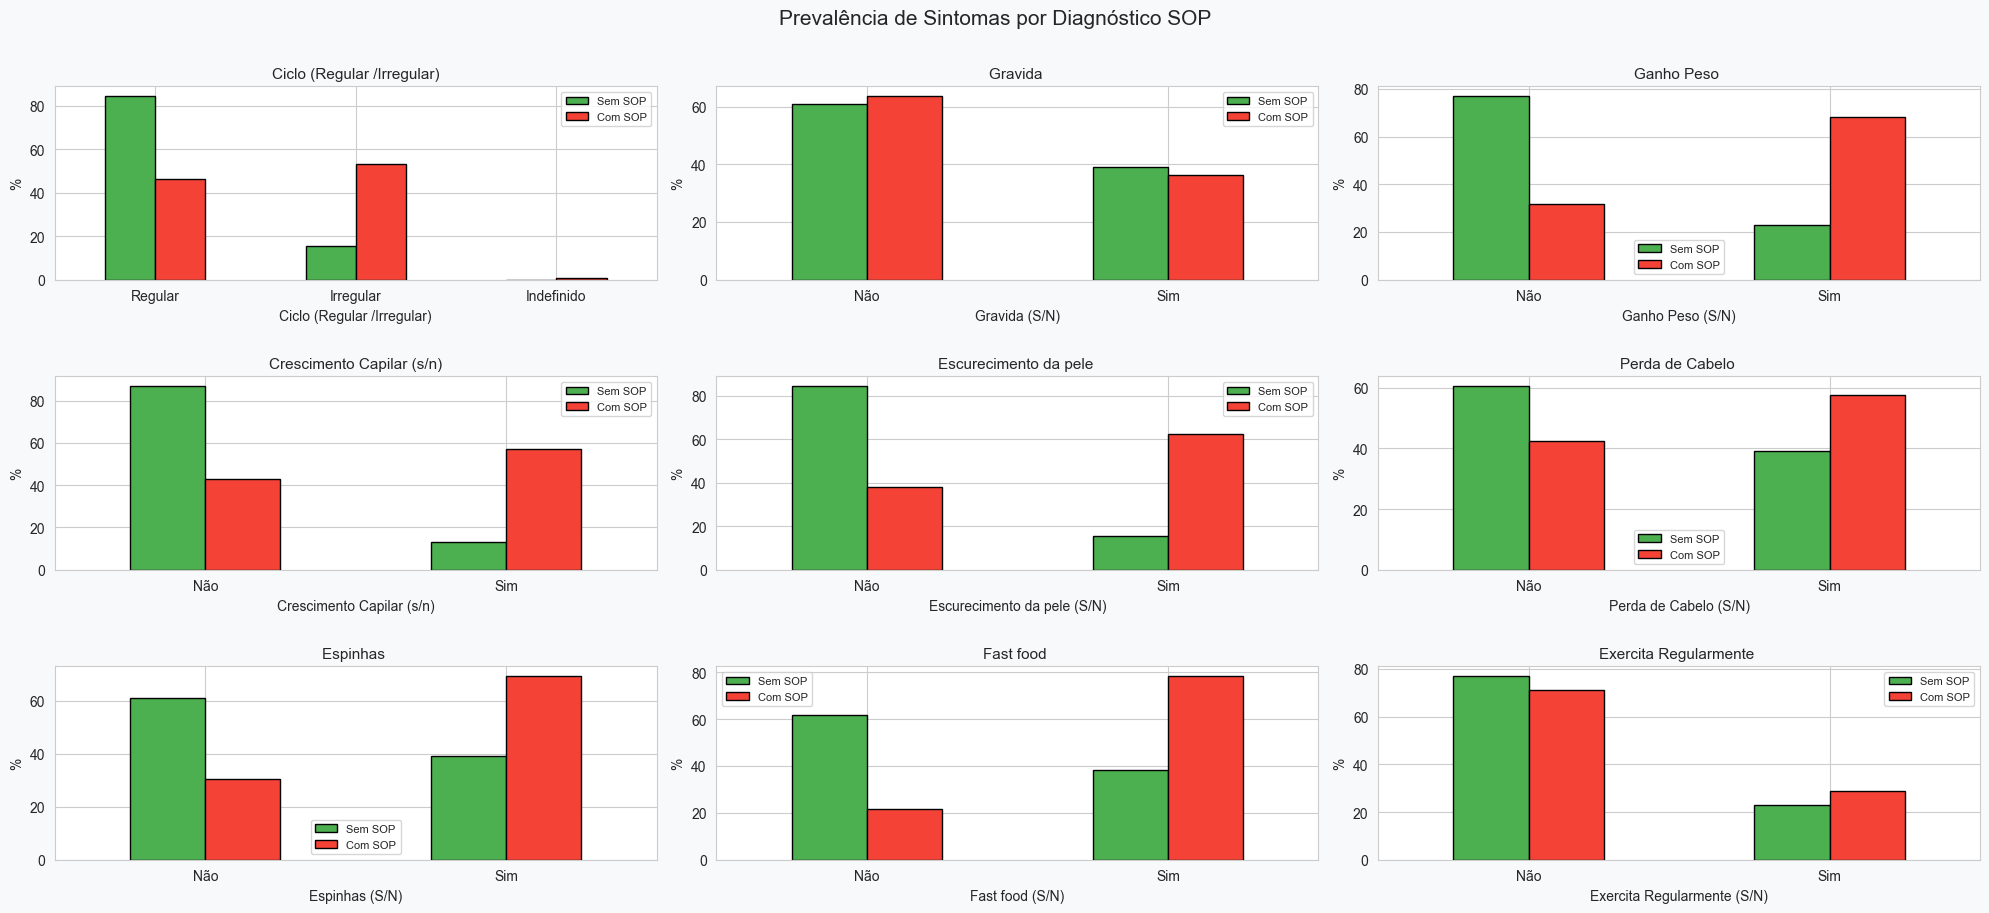

In [207]:
fig, axes = plt.subplots(3, 3, figsize=(20, 9))
axes_flat = axes.flatten()

for i, col in enumerate(colunas_categoricas_list):
    ct = pd.crosstab(X[col], y, normalize='columns') * 100
    ax = axes_flat[i]
    ct.plot(kind='bar', ax=ax, color=['#4CAF50', '#F44336'], edgecolor='black')
    
    ax.set_title(col.replace('(S/N)', ''), fontsize=11)
    ax.set_ylabel('%')
    
    if(col == 'Ciclo (Regular /Irregular)'):
        ax.set_xticks([0, 1, 2])
        ax.set_xticklabels(['Regular', 'Irregular', 'Indefinido'], rotation=0)
    else:
        ax.set_xticks([0, 1]) # Define as posições 0 e 1 (para 'Não' e 'Sim')
        ax.set_xticklabels(['Não', 'Sim'], rotation=0)
    
    #ax.set_xticklabels(['Não', 'Sim'], rotation=0)
    ax.legend(['Sem SOP', 'Com SOP'], fontsize=8)

plt.suptitle('Prevalência de Sintomas por Diagnóstico SOP', fontsize=15, y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5) 
plt.show()

## 3.2 - Histogramas

Vamos exibir somente o histógrama das colunas com valores númericos para analisar a distribuição dos dados da base.

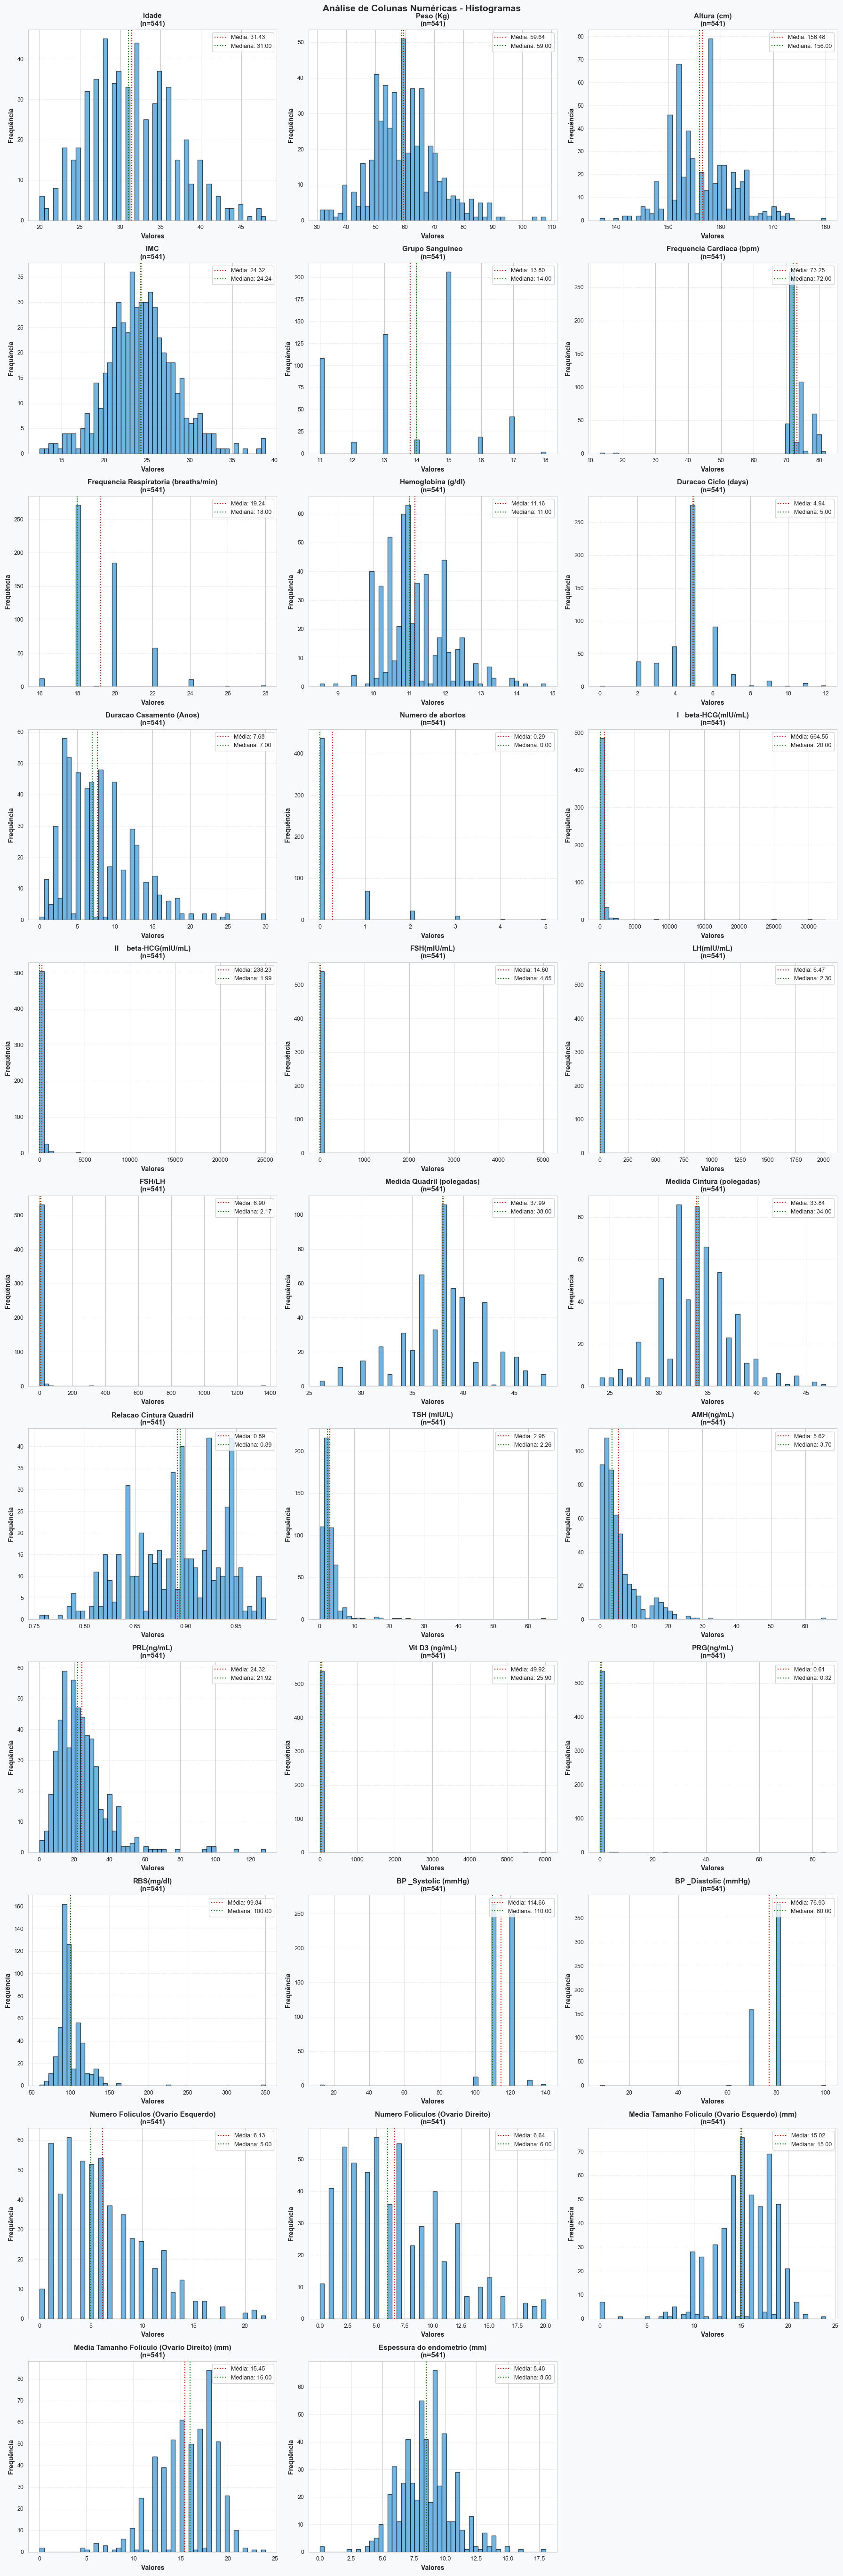

In [208]:
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['font.size'] = 9

# Filtrar apenas colunas numéricas
colunas_numericas = X_sem_categoricas.columns.tolist()

if len(colunas_numericas) > 0:
    n_num = len(colunas_numericas)
    n_cols = 3
    n_rows = (n_num + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(18, 5 * n_rows))
    axes = axes.flatten()
    
    for idx, col in enumerate(colunas_numericas):
        dados_col = pd.to_numeric(dados[col], errors='coerce')
        dados_limpos = dados_col.dropna()
        
        if len(dados_limpos) > 0:
            # Histograma
            axes[idx].hist(dados_limpos, bins=50, edgecolor='black', alpha=0.7, color='#3498db')
            
            # Adicionar estatísticas
            media = dados_limpos.mean()
            mediana = dados_limpos.median()
            
            axes[idx].axvline(media, color='red', linestyle=':', linewidth=1.5, label=f'Média: {media:.2f}')
            axes[idx].axvline(mediana, color='green', linestyle=':', linewidth=1.5, label=f'Mediana: {mediana:.2f}')
            
            axes[idx].set_title(f'{col}\n(n={len(dados_limpos)})', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel('Valores', fontsize=10, fontweight='bold')
            axes[idx].set_ylabel('Frequência', fontsize=10, fontweight='bold')
            axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
            axes[idx].legend(fontsize=9, loc='upper right')
    
    # Remover eixos vazios
    for idx in range(len(colunas_numericas), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle('Análise de Colunas Numéricas - Histogramas', fontsize=14, fontweight='bold', y=0.995)
    plt.subplots_adjust(hspace=0.5) 
    plt.tight_layout()
    plt.show()

### 3.2.1 - Histograma


No histograma é possível notar que a maioria das colunas possuem uma distribuição assimétricas nos dados mas algumas colunas como **Beta-HCG** e **RBS (Glicemia)** possuem uma distribuição assimétrica com alguns dados bem distantes da média, o que pode indicar outliers.

## 3.3 -  Correlação:


Vamos calcular e exibir a matriz de correlação entre as variáveis e o target.


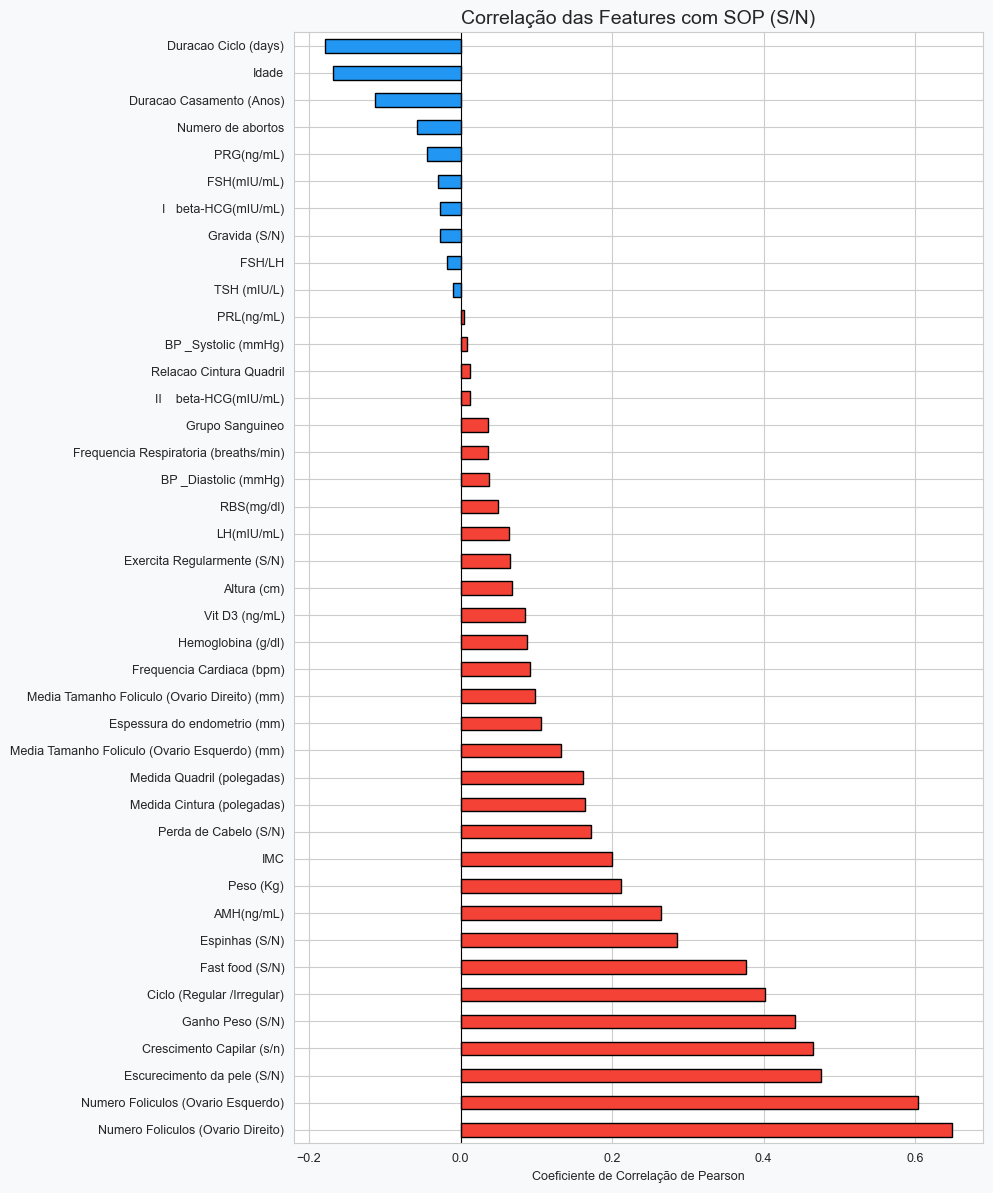

Top 15 features mais correlacionadas com SOP:
Numero Foliculos (Ovario Direito)     0.648
Numero Foliculos (Ovario Esquerdo)    0.603
Escurecimento da pele (S/N)           0.476
Crescimento Capilar (s/n)             0.465
Ganho Peso (S/N)                      0.441
Ciclo (Regular /Irregular)            0.402
Fast food (S/N)                       0.376
Espinhas (S/N)                        0.286
AMH(ng/mL)                            0.264
Peso (Kg)                             0.212
IMC                                   0.200
Duracao Ciclo (days)                  0.178
Perda de Cabelo (S/N)                 0.173
Idade                                 0.169
Medida Cintura (polegadas)            0.165
Name: SOP (S/N), dtype: float64


In [209]:
# Correlação com a variável alvo
df_corr = X.copy()

df_corr[target] = y
corr_target = df_corr.corr()[target].drop(target).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ['#F44336' if v > 0 else '#2196F3' for v in corr_target.values]
corr_target.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Correlação das Features com SOP (S/N)', fontsize=14)
ax.set_xlabel('Coeficiente de Correlação de Pearson')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('Top 15 features mais correlacionadas com SOP:')
print(corr_target.abs().sort_values(ascending=False).head(15).round(3))

## Features mais correlacionadas 
| Feature  								| Correlação  |   
|---------------------------------------|-------|
| Numero Foliculos (Ovario Direito)     | 0.648 |
| Numero Foliculos (Ovario Esquerdo)    | 0.603 |
| Escurecimento da pele (S/N)           | 0.476 |
| Crescimento Capilar (s/n)             | 0.465 |
| Ganho Peso (S/N)                      | 0.441 |
| Ciclo (Regular /Irregular)            | 0.402 |
| Fast food (S/N)                       | 0.376 |
| Espinhas (S/N)                        | 0.286 |
| AMH(ng/mL)                            | 0.264 |
| Peso (Kg)                             | 0.212 |
| IMC                                   | 0.200 |
| Duracao Ciclo (days)                  | 0.178 |
| Perda de Cabelo (S/N)                 | 0.173 |
| Idade                                 | 0.169 |
| Medida Cintura (polegadas)            | 0.165 |

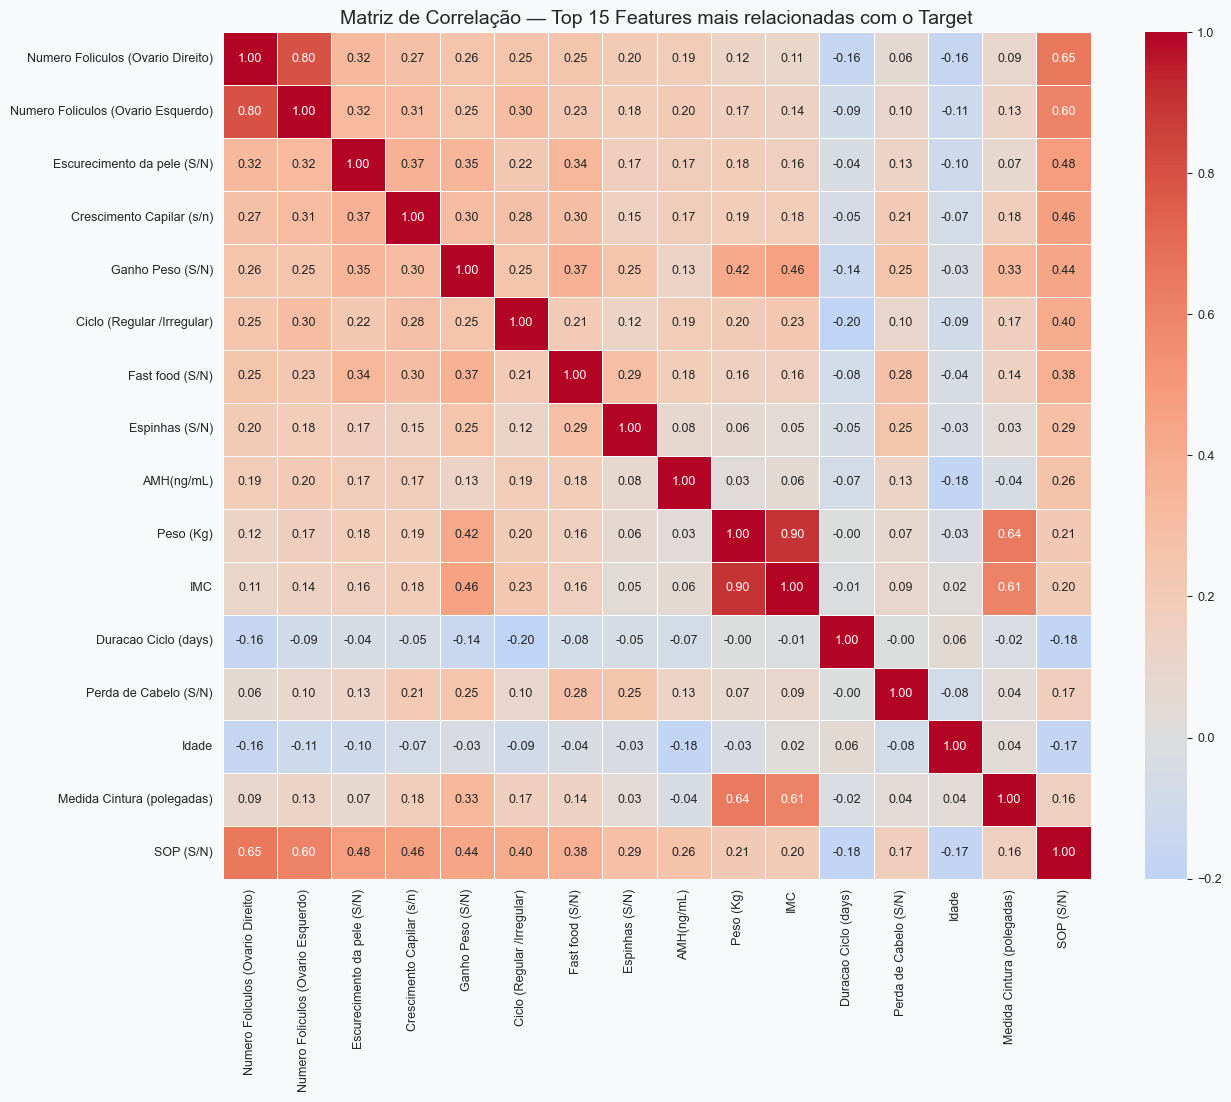

In [210]:
features_mais_relacionadas = corr_target.abs().sort_values(ascending=False).head(15).index.tolist()
features_mais_relacionadas_target = features_mais_relacionadas + [target]

fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = df_corr[features_mais_relacionadas_target].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap= 'coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlação — Top 15 Features mais relacionadas com o Target', fontsize=14)
plt.show()

### 3.3.1 -  Correlação


Podemos identificar através do gráfico que as colunas que mais possuem correlação com a variável alvo são:
- Número de Folículos (Direito e Esquerdo)
- Escurecimento da pele
- Crescimento Capilar

## 3.4 - Descrevendo os dados

In [211]:
dados.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
SOP (S/N),541.0,0.33,0.47,0.00,0.00,0.00,1.00,1.00
Idade,541.0,31.43,5.41,20.00,28.00,31.00,35.00,48.00
Peso (Kg),541.0,59.64,11.03,31.00,52.00,59.00,65.00,108.00
Altura (cm),541.0,156.48,6.03,137.00,152.00,156.00,160.00,180.00
IMC,541.0,24.32,4.05,12.42,21.71,24.24,26.64,38.90
Grupo Sanguineo,541.0,13.80,1.84,11.00,13.00,14.00,15.00,18.00
Frequencia Cardiaca (bpm),541.0,73.25,4.43,13.00,72.00,72.00,74.00,82.00
Frequencia Respiratoria (breaths/min),541.0,19.24,1.69,16.00,18.00,18.00,20.00,28.00
Hemoglobina (g/dl),541.0,11.16,0.87,8.50,10.50,11.00,11.70,14.80
Ciclo (Regular /Irregular),541.0,2.56,0.90,2.00,2.00,2.00,4.00,5.00


### 3.4.1 - Descrevendo os dados


Ao descrever os dados limpos, podemos identificar que as colunas **I beta-HCG(mIU/mL)**, **II beta-HCG(mIU/mL)** e **Vit D3 (ng/mL)** possuem um alto desvio padrão, o que pode indicar outliers.


Iremos normalizar os dados, removendo as colunas binárias, para minimizar ruídos usando StandardScaler. Essa base será usada em um treino futuro.


## 3.5 - Preparando os dados para o Treinamento


Iremos usar 4 cenários de testes para treinar 4 modelos diferentes.


### Modelos:


- **Regressão Logística**
- **KNN**
- **Árvore de Decisão**
- **Random Forest**


### Cenários:


- **Base Original**
- **Base Original + PCA**
- **Base Normalizada**
- **Base Normalizada + PCA**


A ideia é identificar qual modelo se adequa melhor a nossa base e em qual cenário.

A normalização dos dados, removendo as colunas binárias, usando StandardScaler.


In [212]:
RANDOM_STATE = 42

nomes_modelos = ['Regressão Logística', 'KNN', 'Árvore de Decisão', 'Random Forest']
scaler = StandardScaler()
pca = PCA(n_components=3)

# Segregação dados de treinamento e teste

X = dados.drop(columns=[target])
y = dados[target]

# Base Original
X_train_base_orig, X_test_base_orig, y_train_base_orig, y_test_base_orig = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# Base Original + PCA
X_pca = pca.fit_transform(X) 
df_pca = pd.DataFrame(data=X_pca, columns=['PCA 1', 'PCA 2', 'PCA 3']) 
X_train_base_orig_pca, X_test_base_orig_pca, _, _ = train_test_split(df_pca, y, test_size=0.2, random_state=RANDOM_STATE)

# Base Normalizada
X_train_scaled = scaler.fit_transform(X_train_base_orig) 
X_test_scaled = scaler.transform(X_test_base_orig) 

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Base Normalizada + PCA
X_scaled = pd.concat([pd.DataFrame(X_train_scaled, columns=X.columns), pd.DataFrame(X_test_scaled, columns=X.columns)], axis=0) 
X_scaled_pca = pca.fit_transform(X_scaled) 
df_scaled_pca = pd.DataFrame(data=X_scaled_pca, columns=['PCA 1', 'PCA 2', 'PCA 3'])
X_train_scaled_pca, X_test_scaled_pca, _, _ = train_test_split(df_scaled_pca, y, test_size=0.2, random_state=RANDOM_STATE)

#result = pd.concat([df_pca, X_scaled[target]], axis=1)

tipos_treinos = {
    'Treino 1 - Base Original': (X_train_base_orig, X_test_base_orig, y_train_base_orig, y_test_base_orig),
    'Treino 2 - Base Original + PCA': (X_train_base_orig_pca, X_test_base_orig_pca, y_train_base_orig, y_test_base_orig),
    'Treino 3 - Base Normalizada': (X_train_scaled, X_test_scaled, y_train_base_orig, y_test_base_orig),
    'Treino 4 - Base Normalizada + PCA': (X_train_scaled_pca, X_test_scaled_pca, y_train_base_orig, y_test_base_orig)
}

# 4 - Modelagem


Vamos começar com o primeiro treinamento.


A classe **FactoryModelo** será usada como fábrica de modelos para o nosso treinamento.


In [213]:



class FactoryModelo:
    def __init__(self, random_state=42):
        self.RANDOM_STATE = random_state

    def construir_modelo(self, nome):
        try:
            # Dicionário que mapeia nomes para funções construtoras
            self._modelos = {
                "Regressão Logística": lambda: LogisticRegression(random_state=self.RANDOM_STATE, max_iter=1000),
                "KNN": lambda: KNeighborsClassifier(n_neighbors=7),
                "Árvore de Decisão": lambda: DecisionTreeClassifier(random_state=self.RANDOM_STATE, max_depth=5),
                "Random Forest": lambda: RandomForestClassifier(random_state=self.RANDOM_STATE, n_estimators=200, max_depth=5),
            }
            
            return self._modelos[nome]()  # chama a função correspondente
        except KeyError:
            raise ValueError(f"Modelo '{nome}' não está disponível na fábrica.")


## 4.1 Validação cruzada


Vamos usar a técnica de validação cruzada para identificar qual modelo teve a maior precisão no treinamento com a nossa base de dados.

In [214]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
modelos_treinados = {}

from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

for nome in nomes_modelos:
    for treino_name, (X_train, X_test, y_train, y_test) in tipos_treinos.items():
        modelo = FactoryModelo().construir_modelo(nome)
        nome_completo = nome + ' - ' + treino_name
        modelos_treinados[nome_completo] = modelo
        X_tr = X_train
        scores_acc = cross_val_score(modelo, X_tr, y_train, cv=cv, scoring='accuracy')
        scores_f1 = cross_val_score(modelo, X_tr, y_train, cv=cv, scoring='f1')
        scores_recall = cross_val_score(modelo, X_tr, y_train, cv=cv, scoring='recall')
        
        cv_results[nome_completo] = {
            'Accuracy': f'{scores_acc.mean():.4f} ± {scores_acc.std():.4f}',
            'F1-Score': f'{scores_f1.mean():.4f} ± {scores_f1.std():.4f}',
            'Recall': f'{scores_recall.mean():.4f} ± {scores_recall.std():.4f}',
            'acc_mean': scores_acc.mean(),
            'f1_mean': scores_f1.mean(),
            'recall_mean': scores_recall.mean()
        }
        print(f'{nome_completo:60s} | Acc: {scores_acc.mean():.4f} | F1: {scores_f1.mean():.4f} | Recall: {scores_recall.mean():.4f}')

print('\nValidação cruzada concluída.')

C:\Users\fgsil\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\fgsil\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

Regressão Logística - Treino 1 - Base Original               | Acc: 0.8771 | F1: 0.8117 | Recall: 0.7862
Regressão Logística - Treino 2 - Base Original + PCA         | Acc: 0.6620 | F1: 0.0000 | Recall: 0.0000
Regressão Logística - Treino 3 - Base Normalizada            | Acc: 0.8980 | F1: 0.8462 | Recall: 0.8276
Regressão Logística - Treino 4 - Base Normalizada + PCA      | Acc: 0.6643 | F1: 0.0000 | Recall: 0.0000
KNN - Treino 1 - Base Original                               | Acc: 0.6991 | F1: 0.4204 | Recall: 0.3310
KNN - Treino 2 - Base Original + PCA                         | Acc: 0.6135 | F1: 0.2594 | Recall: 0.2000
KNN - Treino 3 - Base Normalizada                            | Acc: 0.8773 | F1: 0.7948 | Recall: 0.7034
KNN - Treino 4 - Base Normalizada + PCA                      | Acc: 0.6066 | F1: 0.2527 | Recall: 0.2000
Árvore de Decisão - Treino 1 - Base Original                 | Acc: 0.8286 | F1: 0.7329 | Recall: 0.7034
Árvore de Decisão - Treino 2 - Base Original + PCA     

### 4.1.1 - Exibição dos resultados

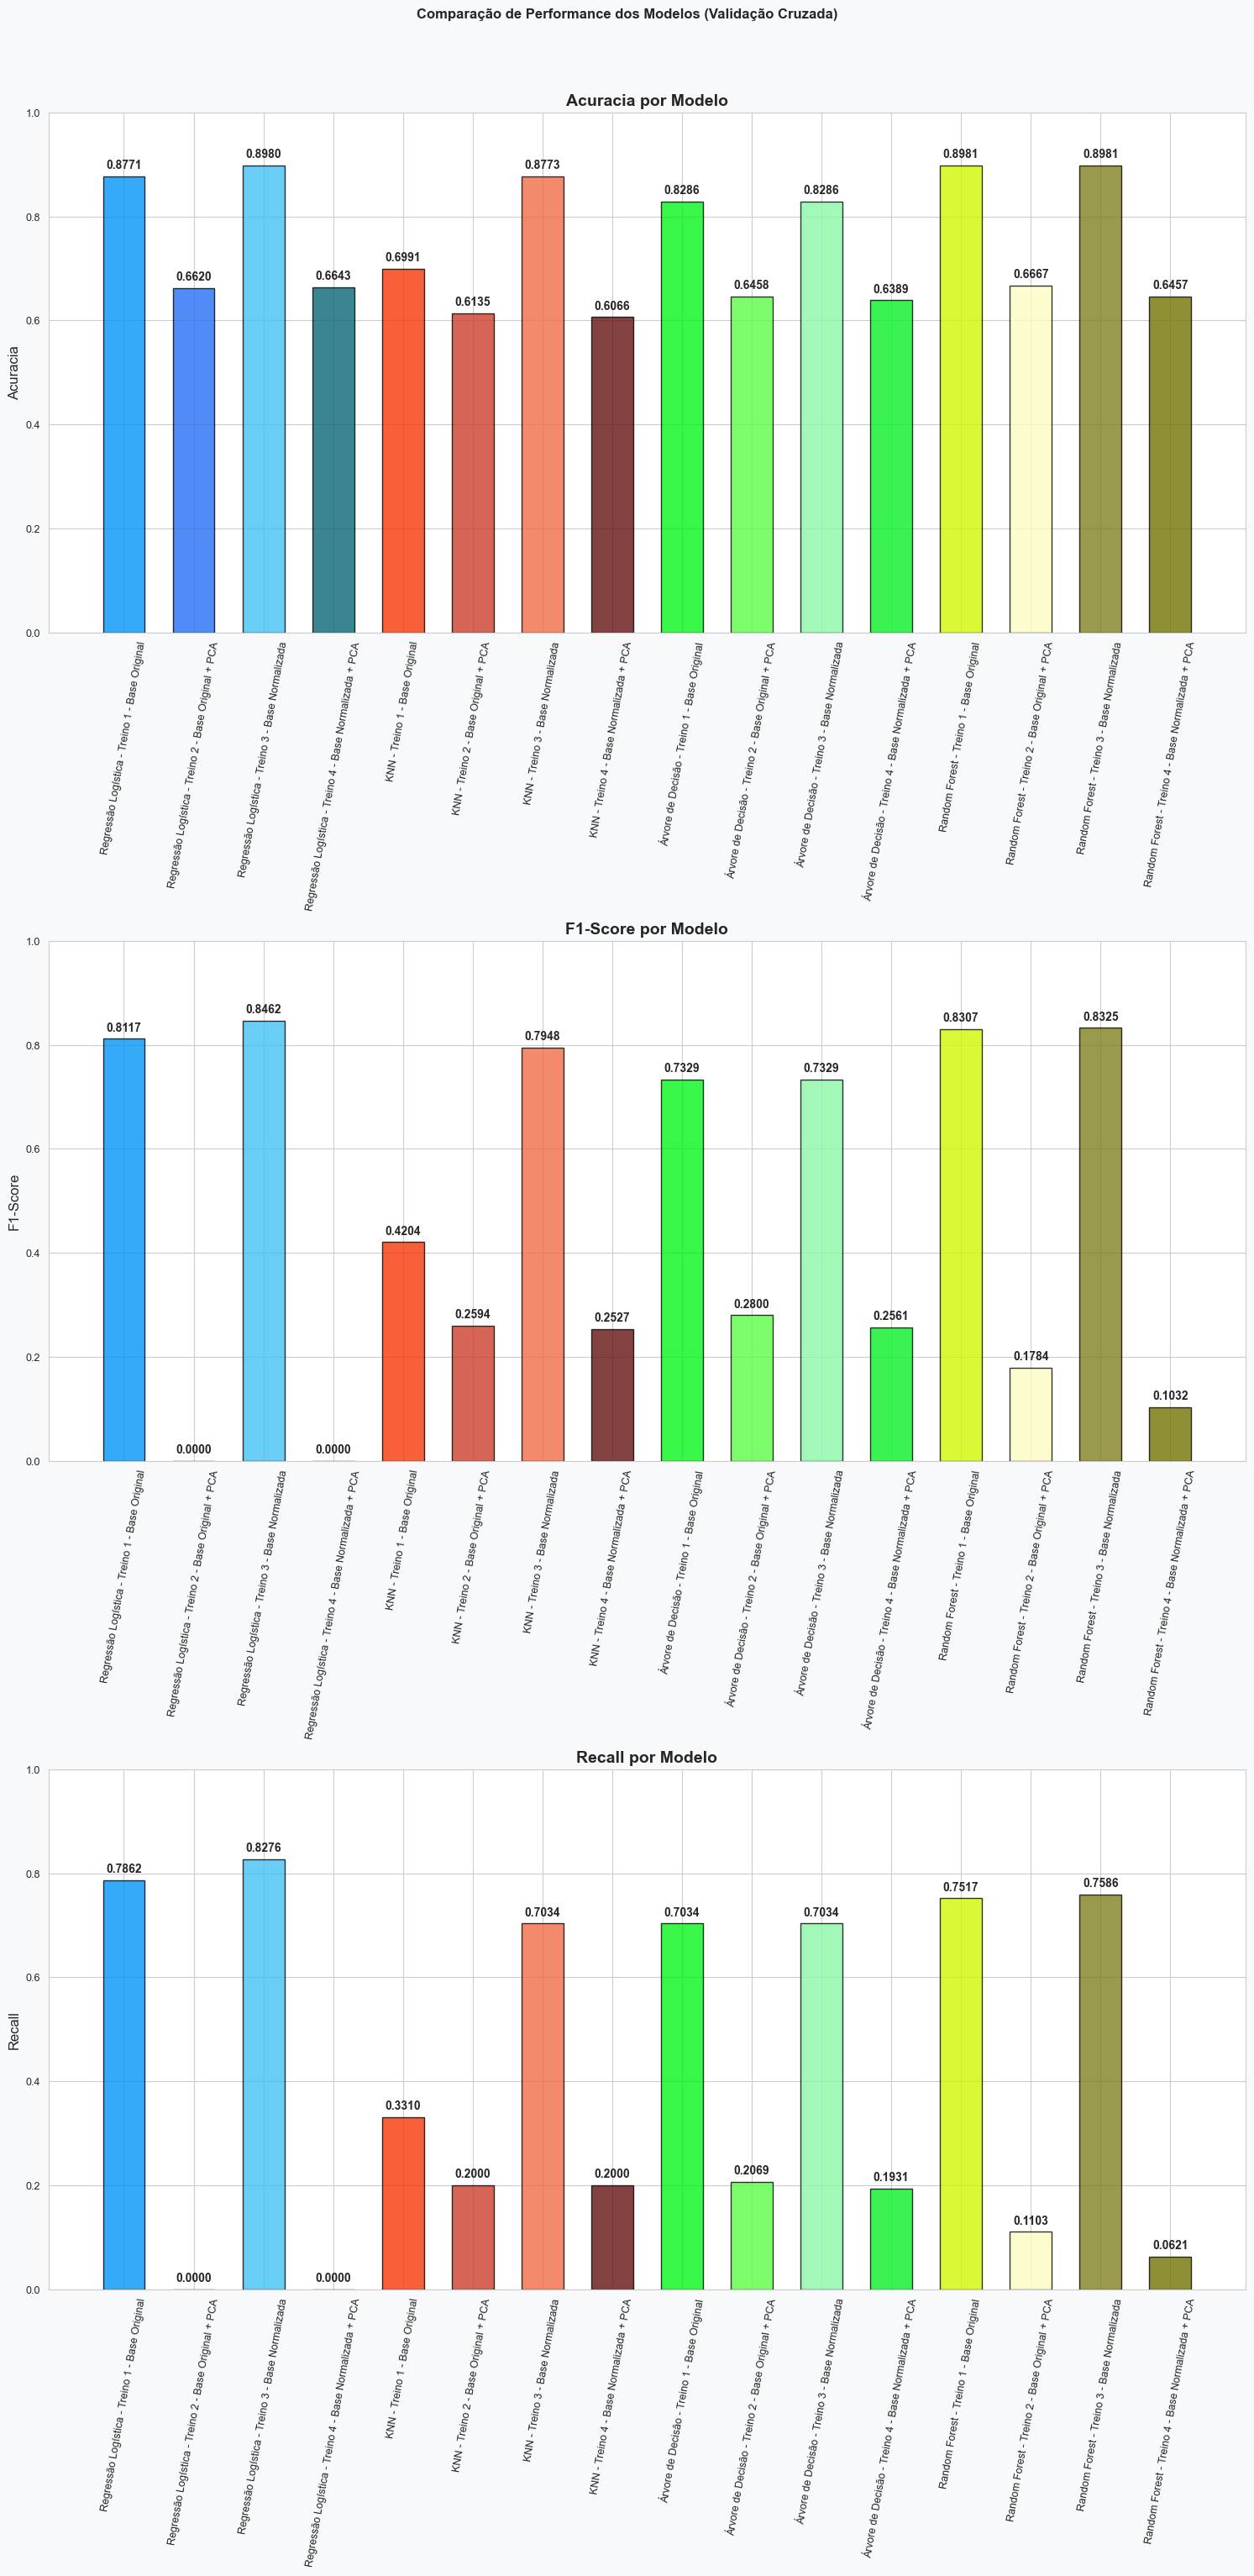


 Melhor modelo: Regressão Logística - Treino 3 - Base Normalizada
   Accuracy: 0.8980 ± 0.0379
   F1-Score: 0.8462 ± 0.0546
   Recall: 0.8276 ± 0.0378


In [215]:
# Preparar dados para visualização
model_names = list(modelos_treinados.keys())
accuracy_scores = [cv_results[name]['acc_mean'] for name in model_names]
f1_scores = [cv_results[name]['f1_mean'] for name in model_names]
recall_scores = [cv_results[name]['recall_mean'] for name in model_names]

# Criar gráfico de barras
fig, axes = plt.subplots(3, 1, figsize=(15, 30))
axes_flat = axes.flatten()

# Cores para distinguir cada modelo
model_colors = ["#0395f7", "#266ef5", "#44c1f3", "#096777",
                "#f73808", "#cc3e2e", "#f06d46", "#661212",
                "#06f51a", "#5cfc47", "#8bf7a6e3", "#08f12781",
                "#d2f703", "#fdfcc4", "#80811e", "#7375046C"]  
# Acuracia
bars1 = axes_flat[0].bar(model_names, accuracy_scores, color=model_colors, alpha=0.8, edgecolor='black', width=0.6)
axes_flat[0].set_title('Acuracia por Modelo', fontsize=14, fontweight='bold')
axes_flat[0].set_ylabel('Acuracia', fontsize=12)
axes_flat[0].set_ylim(0, 1.0)
axes_flat[0].tick_params(axis='x', rotation=80)

# F1-Score
bars2 = axes_flat[1].bar(model_names, f1_scores, color=model_colors, alpha=0.8, edgecolor='black', width=0.6)
axes_flat[1].set_title('F1-Score por Modelo', fontsize=14, fontweight='bold')
axes_flat[1].set_ylabel('F1-Score', fontsize=12)
axes_flat[1].set_ylim(0, 1.0)
axes_flat[1].tick_params(axis='x', rotation=80)

# Recall
bars3 = axes_flat[2].bar(model_names, recall_scores, color=model_colors, alpha=0.8, edgecolor='black', width=0.6)
axes_flat[2].set_title('Recall por Modelo', fontsize=14, fontweight='bold')
axes_flat[2].set_ylabel('Recall', fontsize=12)
axes_flat[2].set_ylim(0, 1.0)
axes_flat[2].tick_params(axis='x', rotation=80)

# Adicionar valores nas barras
for ax, bars, scores in zip(axes_flat, [bars1, bars2, bars3], [accuracy_scores, f1_scores, recall_scores]):
    for bar, score in zip(bars, scores):
        height = bar.get_height()       
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Comparação de Performance dos Modelos (Validação Cruzada)', fontsize=12, fontweight='bold', y=1.02)
plt.subplots_adjust(hspace=1.5) 
plt.tight_layout()
plt.show()

# Identificar melhor modelo
melhor_modelo = max(cv_results.keys(), key=lambda x: cv_results[x]['f1_mean'])
print(f"\n Melhor modelo: {melhor_modelo}")
print(f"   Accuracy: {cv_results[melhor_modelo]['Accuracy']}")
print(f"   F1-Score: {cv_results[melhor_modelo]['F1-Score']}")
print(f"   Recall: {cv_results[melhor_modelo]['Recall']}")

### 4.1.1 - Resultados


Após executar a validação cruzada, temos que o modelo que melhor performou com a nossa base de dados foi **Regressão Logística - Treino 3 - Base Normalizada**, com F1-Score de **0.8462**.

## 4.2 - Treinamento

Agora vamos treinar todos os modelos de fato.

In [216]:
# Treinar todos os modelos e avaliar no conjunto de teste

resultados = {}
modelos_treinados = {}

for nome in nomes_modelos:
    for treino_name, (X_train, X_test, y_train, y_test) in tipos_treinos.items():
        modelo = FactoryModelo().construir_modelo(nome)
        nome_completo = nome + ' - ' + treino_name
   
        X_tr =  X_train
        X_te =  X_test
        
        modelo.fit(X_tr, y_train)
        modelos_treinados[nome_completo] = modelo
        
        y_pred = modelo.predict(X_te)
        y_proba = modelo.predict_proba(X_te)[:, 1]
        
        resultados[nome_completo] = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred),
            'AUC-ROC': roc_auc_score(y_test, y_proba),
            'y_pred': y_pred,
            'y_proba': y_proba
        }

C:\Users\fgsil\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\fgsil\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 5 - Avaliação dos dados

In [217]:
# Tabela de resultados
df_resultados = pd.DataFrame({name: {k: v for k, v in vals.items() if k not in ['y_pred', 'y_proba']}
                            for name, vals in resultados.items()}).T.round(4)

df_resultados = df_resultados.sort_values('F1-Score', ascending=False)
print('=== Resultados no Conjunto de Teste ===\n')
df_resultados

=== Resultados no Conjunto de Teste ===



,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Árvore de Decisão - Treino 3 - Base Normalizada,0.8440,0.6923,0.8438,0.7606,0.8705
Árvore de Decisão - Treino 1 - Base Original,0.8440,0.6923,0.8438,0.7606,0.8722
Random Forest - Treino 3 - Base Normalizada,0.8716,0.8750,0.6562,0.7500,0.9497
Regressão Logística - Treino 1 - Base Original,0.8532,0.7857,0.6875,0.7333,0.8640
Random Forest - Treino 1 - Base Original,0.8624,0.8696,0.6250,0.7273,0.9489
Regressão Logística - Treino 3 - Base Normalizada,0.8532,0.8333,0.6250,0.7143,0.9245
KNN - Treino 3 - Base Normalizada,0.8440,0.8571,0.5625,0.6792,0.9229
KNN - Treino 1 - Base Original,0.6881,0.4545,0.3125,0.3704,0.5818
KNN - Treino 2 - Base Original + PCA,0.6606,0.3684,0.2188,0.2745,0.4746
KNN - Treino 4 - Base Normalizada + PCA,0.6422,0.2667,0.1250,0.1702,0.4724


## 5.1 - Curva ROC (Receiver Operating Characteristic)

Vamos exibir a curva ROC dos nossos modelos para verificar a relação entre a taxa de verdadeiros positivos (sensibilidade) e a taxa de falsos positivos.

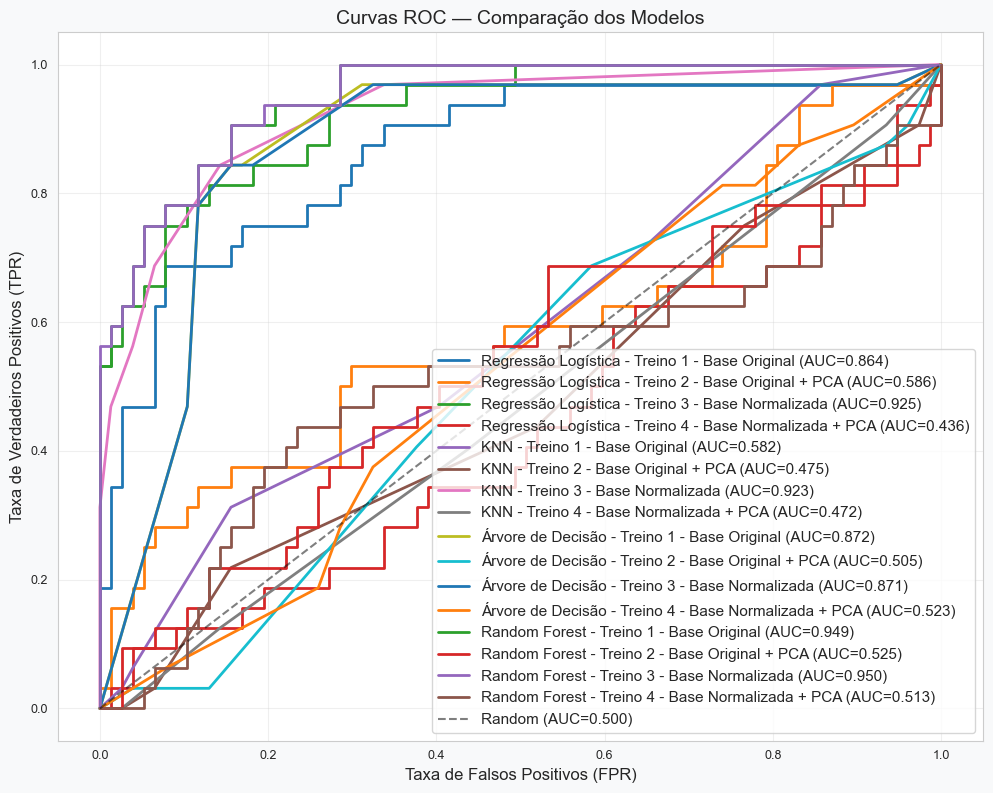

In [218]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

fig, ax = plt.subplots(figsize=(10, 8))

for nome, valores in resultados.items():
    y_score = valores['y_proba']
    falso_positivo, verdadeiro_positivo, _ = roc_curve(y_test, y_score)
    ax.plot(falso_positivo, verdadeiro_positivo, linewidth=2, label=f"{nome} (AUC={valores['AUC-ROC']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.500)')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Comparação dos Modelos', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5.2 - Matriz de Confusão

Vamos exibir a matriz de confusão dos nossos modelos para verificar a relação entre a taxa de verdadeiros positivos e a taxa de falsos positivos.

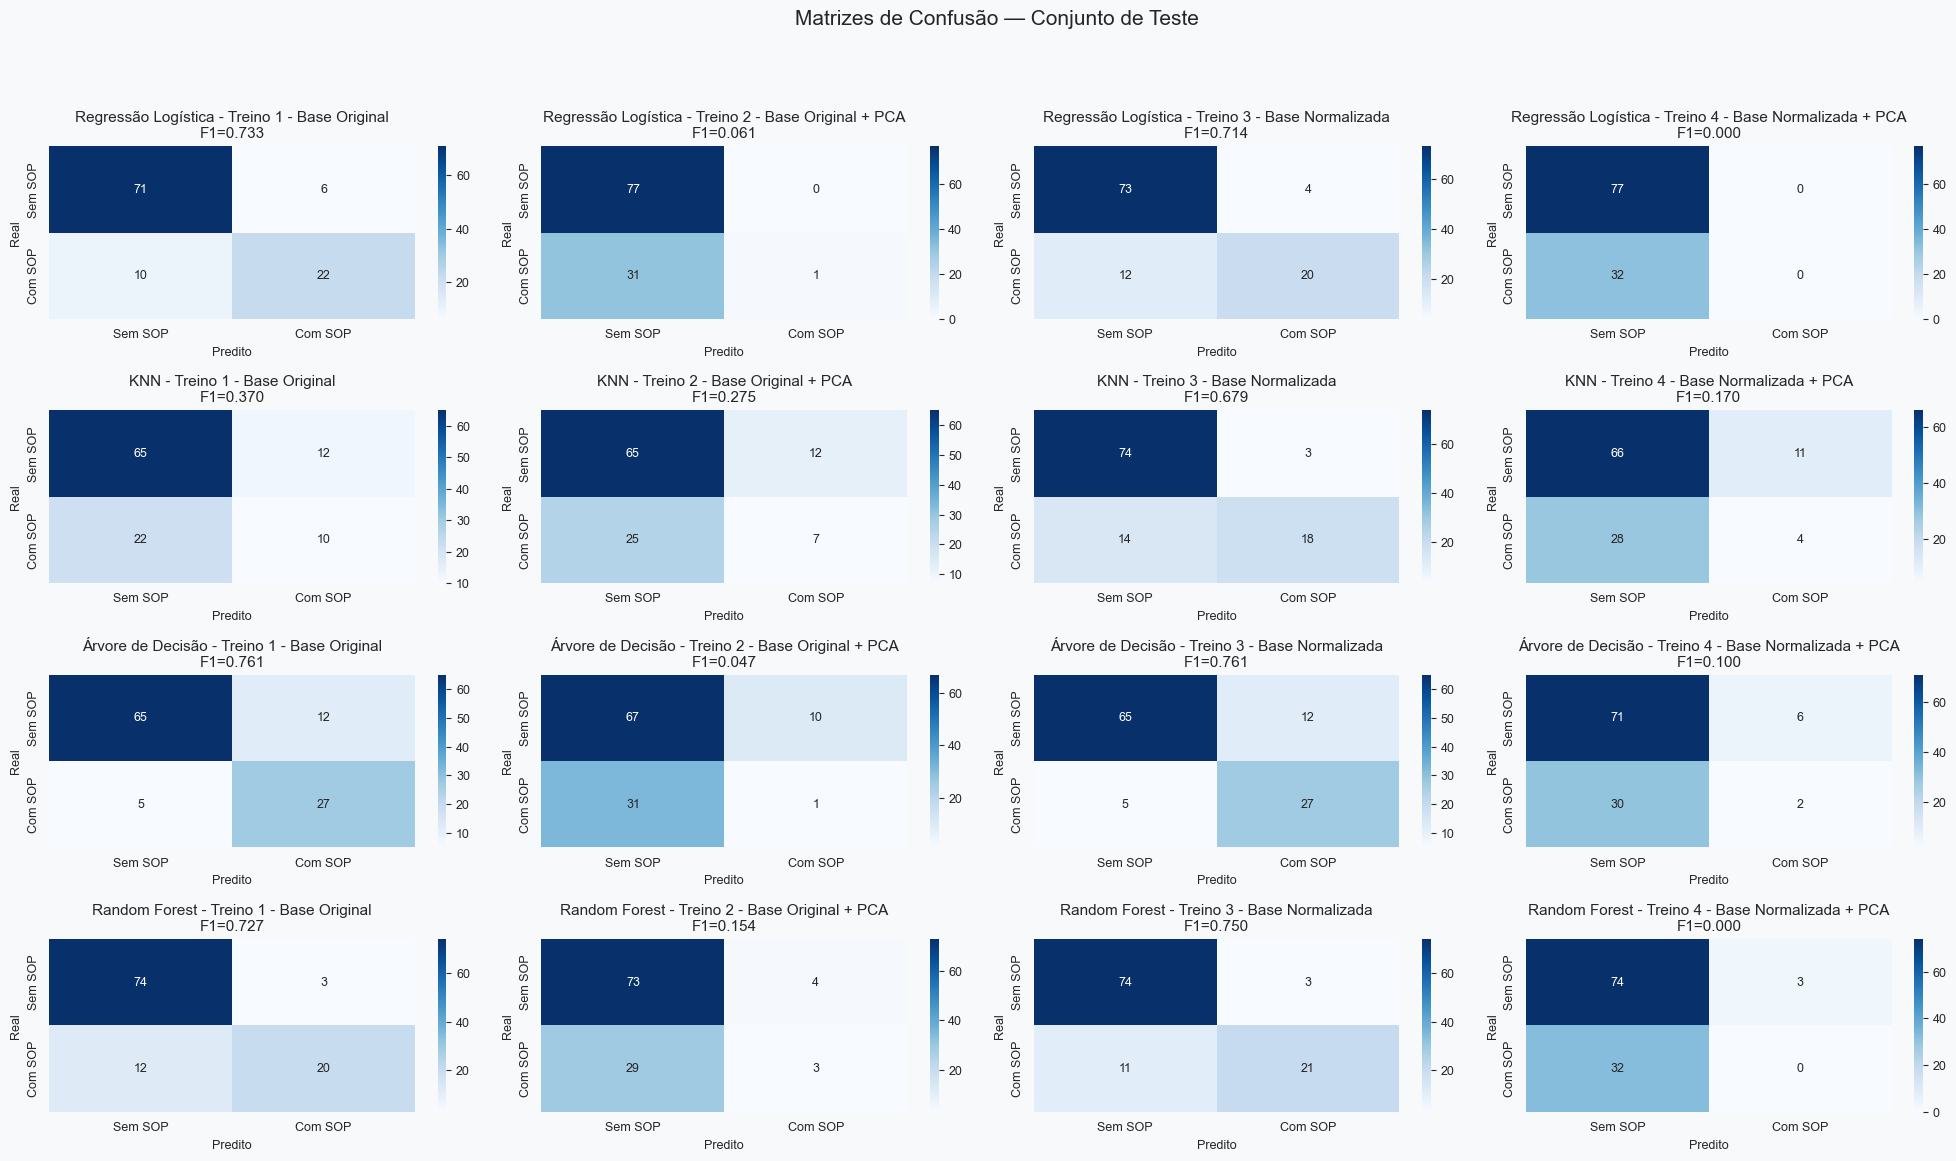

In [219]:
fig, axes = plt.subplots(4, 4, figsize=(20, 11))

resultados_confusao =  resultados.items() 

for i, (nome, valores) in enumerate(resultados_confusao):
    cm = confusion_matrix(y_test, valores['y_pred'])
    ax = axes[i // 4, i % 4]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sem SOP', 'Com SOP'],
                yticklabels=['Sem SOP', 'Com SOP'])
    ax.set_title(f'{nome}\nF1={valores["F1-Score"]:.3f}', fontsize=11)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')    

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

In [220]:
for name, model in modelos_treinados.items():
    print(f'\n=== Relatório de Classificação - {name} ===')
    print(classification_report(y_test, resultados[name]['y_pred'], target_names=['Sem SOP (0)', 'Com SOP (1)']))


=== Relatório de Classificação - Regressão Logística - Treino 1 - Base Original ===
              precision    recall  f1-score   support

 Sem SOP (0)       0.88      0.92      0.90        77
 Com SOP (1)       0.79      0.69      0.73        32

    accuracy                           0.85       109
   macro avg       0.83      0.80      0.82       109
weighted avg       0.85      0.85      0.85       109


=== Relatório de Classificação - Regressão Logística - Treino 2 - Base Original + PCA ===
              precision    recall  f1-score   support

 Sem SOP (0)       0.71      1.00      0.83        77
 Com SOP (1)       1.00      0.03      0.06        32

    accuracy                           0.72       109
   macro avg       0.86      0.52      0.45       109
weighted avg       0.80      0.72      0.61       109


=== Relatório de Classificação - Regressão Logística - Treino 3 - Base Normalizada ===
              precision    recall  f1-score   support

 Sem SOP (0)       0.86    

C:\Users\fgsil\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fgsil\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\fgsil\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

## 5.4 - Avaliação dos resultados


A normalização da base só surtiu um grande efeito positivo no teste **KNN - Treino 3**. Em todos os outros testes o efeito foi quase nulo e em alguns casos até prejudicou a predição dos dados.


O PCA prejudicou todos os modelos. Isso demonstra que a base não é adequada para uso do PCA, pois não existe um grande volume de variáveis e não há correlações extremamente fortes entre a variável target e as demais.


Os modelos que melhor performaram foram **Random Forest** e **Árvore de Decisão** com a base normalizada e sem aplicação de PCA.


O modelo **Árvore de Decisão - Treino 3 - Base Normalizada** foi o modelo que melhor conseguiu prever pacientes *Com SOP*, mas errou 4x mais que o **Random Forest - Treino 3 - Base Normalizada**, por isso não foi selecionado.


### Resultados Random Forest


 - O **Random Forest** teve uma acurácia de 87% sendo que acertou 74 casos de negativo para **SOP** e 21 casos positivos.
 - 03 pacientes *Sem SOP* foram erroneamente diagnosticados
 - 11 pacientes *Com SOP* foram erroneamente diagnosticados
 - O **recall** dos casos *Sem SOP* foi de **96%**. O que significa que a cada 20 pacientes 1 será diagnosticada erroneamente.
 - O **recall** dos casos *Cem SOP* foi de **66%**. O que significa que a cada 3 pacientes 1 será diagnosticada erroneamente.


### Relatório de Classificação
#### Random Forest - Treino 3 - Base Normalizada


| Classe        | Precision | Recall | F1-score | Support |
|---------------|-----------|--------|----------|---------|
| Sem SOP (0)   | 0.87      | 0.96   | 0.91     | 77      |
| Com SOP (1)   | 0.88      | 0.66   | 0.75     | 32      |
| **Accuracy**  |           |        | 0.87     | 109     |
| Macro avg     | 0.87      | 0.81   | 0.83     | 109     |
| Weighted avg  | 0.87      | 0.87   | 0.87     | 109     |




### Resultados Árvore de Decisão


 - O **Árvore de Decisão** teve uma acurácia de 84% sendo que acertou 65 casos de negativo para **SOP** e 27 casos positivos.
 - 12 pacientes *Sem SOP* foram erroneamente diagnosticados
 - 05 pacientes *Com SOP* foram erroneamente diagnosticados
 - O **recall** dos casos *Sem SOP* foi de **84%**. O que significa que a cada 20 pacientes ± 3 serão diagnosticadas erroneamente.
 - O **recall** dos casos *Cem SOP* foi de **69%**. O que significa que a cada 3 pacientes 1 será diagnosticada erroneamente.


### Relatório de Classificação
#### Árvore de Decisão - Treino 3 - Base Normalizada


| Classe        | Precision | Recall | F1-score | Support |
|---------------|-----------|--------|----------|---------|
| Sem SOP (0)   | 0.93      | 0.84   | 0.88     | 77      |
| Com SOP (1)   | 0.85      | 0.69   | 0.76     | 32      |
| **Accuracy**  |           |        | 0.84     | 109     |
| Macro avg     | 0.81      | 0.84   | 0.82     | 109     |
| Weighted avg  | 0.86      | 0.84   | 0.85     | 109     |




### Conclusão
Podemos notar que por mais que o modelo **'Random Forest'** seja o mais eficiente até o momento, o recall para pacientes da classe 'Com SOP' ainda está baixo. O modelo conseguiu prever corretamente somente 66% dos casos positivos. É interessante notar que o modelo **'Árvore de Decisão'** tem uma precisão maior para prever casos de SOP, mas a média ponderada do recall é melhor no **'Random Forest'**.





In [221]:
# Tabela de resultados
df_resultados = pd.DataFrame({name: {k: v for k, v in vals.items() if k not in ['y_pred', 'y_proba']}
                            for name, vals in resultados.items()}).T.round(4)

df_resultados = df_resultados.sort_values('F1-Score', ascending=False)
print('=== Resultados no Conjunto de Teste ===\n')
df_resultados

=== Resultados no Conjunto de Teste ===



,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Árvore de Decisão - Treino 3 - Base Normalizada,0.8440,0.6923,0.8438,0.7606,0.8705
Árvore de Decisão - Treino 1 - Base Original,0.8440,0.6923,0.8438,0.7606,0.8722
Random Forest - Treino 3 - Base Normalizada,0.8716,0.8750,0.6562,0.7500,0.9497
Regressão Logística - Treino 1 - Base Original,0.8532,0.7857,0.6875,0.7333,0.8640
Random Forest - Treino 1 - Base Original,0.8624,0.8696,0.6250,0.7273,0.9489
Regressão Logística - Treino 3 - Base Normalizada,0.8532,0.8333,0.6250,0.7143,0.9245
KNN - Treino 3 - Base Normalizada,0.8440,0.8571,0.5625,0.6792,0.9229
KNN - Treino 1 - Base Original,0.6881,0.4545,0.3125,0.3704,0.5818
KNN - Treino 2 - Base Original + PCA,0.6606,0.3684,0.2188,0.2745,0.4746
KNN - Treino 4 - Base Normalizada + PCA,0.6422,0.2667,0.1250,0.1702,0.4724


## 5.5 - Ajustes de parâmetros


Após a primeira etapa de treinamento, pudemos identificar que os 2 melhores modelos e cenários são **Random Forest - Treino 3 - Base Normalizada** e **Árvore de Decisão - Treino 3 - Base Normalizada**.


Com isso, vamos tentar melhorar a performance desses modelos executando validação cruzada para identificar os melhores parâmetros para treiná-los.



### 5.5.1 - Random Forest

In [222]:



param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [5, 10, 15, 20, None]
}

clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train_scaled, y_train_base_orig)

print("Melhores parâmetros:", grid_search.best_params_)

Melhores parâmetros: {'max_depth': 10, 'n_estimators': 100}


### 5.5.2 - Árvore de Decisão

In [223]:



param_grid_av = {"max_depth": [1,2,3,4, 5,6, 7,8,9, 10,11,12,13,14, 15, None]}
grid_av = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_av, cv=5, scoring="accuracy")
grid_av.fit(X_train_scaled, y_train_base_orig)

print("Melhor profundidade:", grid_av.best_params_)


Melhor profundidade: {'max_depth': 3}


### 5.5.3 - Resultado dos melhores parâmetros


Podemos observar que para o **Random Forest** os melhores parâmetros são *max_depth= 10 e n_estimators= 100* e para **Árvore de Decisão** é *max_depth = 3*.


Agora que temos os parâmetros, vamos testar nosso modelo novamente para esses novos parâmetros.


=== Resultados no Conjunto de Teste ===



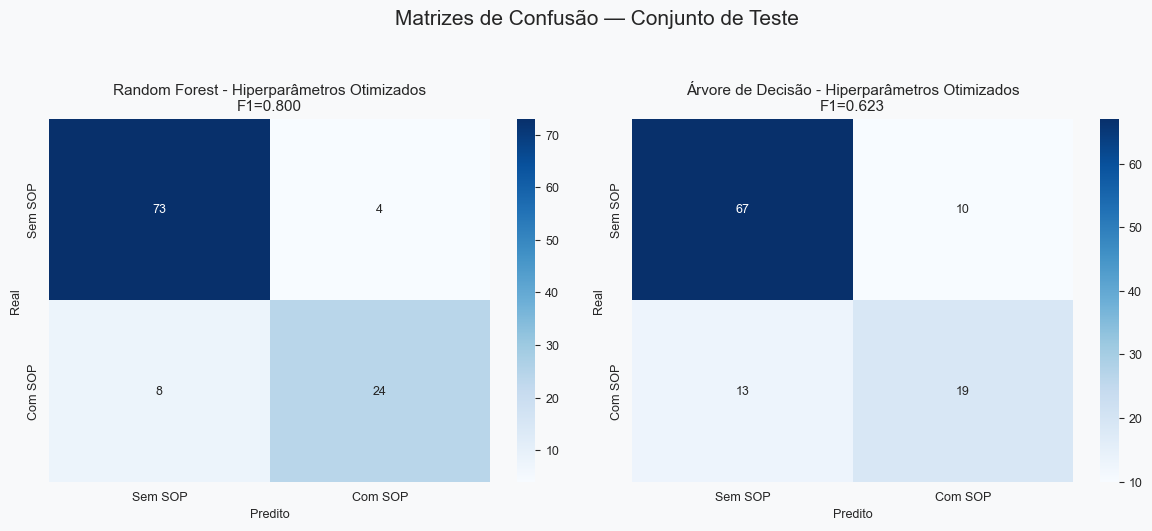

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Random Forest - Hiperparâmetros Otimizados,0.8899,0.8571,0.7500,0.800,0.9554
Árvore de Decisão - Hiperparâmetros Otimizados,0.7890,0.6552,0.5938,0.623,0.8975


In [224]:

melhor_random_forest =  RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
melhor_arvore_decisao = DecisionTreeClassifier(random_state=42, max_depth=3)
from sklearn.pipeline import Pipeline

melhores_modelos = {
    'Random Forest - Hiperparâmetros Otimizados': melhor_random_forest,
    'Árvore de Decisão - Hiperparâmetros Otimizados': melhor_arvore_decisao
}

resultados_pipelines_treinadas = {}
pipelines_treinadas = {}

for nome, modelo in melhores_modelos.items():

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", modelo)
    ])

    X_tr =  X_train_base_orig
    X_te =  X_test_base_orig
    
    pipeline.fit(X_tr, y_train)
    pipelines_treinadas[nome] = pipeline
    
    y_pred = pipeline.predict(X_te)
    y_proba = pipeline.predict_proba(X_te)[:, 1]
    
    resultados_pipelines_treinadas[nome] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

# Tabela de resultados
df_resultados_pipelines_treinadas = pd.DataFrame({name: {k: v for k, v in vals.items() if k not in ['y_pred', 'y_proba']}
                            for name, vals in resultados_pipelines_treinadas.items()}).T.round(4)

df_resultados_pipelines_treinadas = df_resultados_pipelines_treinadas.sort_values('F1-Score', ascending=False)
print('=== Resultados no Conjunto de Teste ===\n')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

resultados_confusao =  resultados_pipelines_treinadas.items() 

for i, (nome, valores) in enumerate(resultados_confusao):
    cm = confusion_matrix(y_test, valores['y_pred'])
    ax = axes[i]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sem SOP', 'Com SOP'],
                yticklabels=['Sem SOP', 'Com SOP'])
    ax.set_title(f'{nome}\nF1={valores["F1-Score"]:.3f}', fontsize=11)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')    

plt.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()
df_resultados_pipelines_treinadas

In [225]:
melhor_modelo = pipelines_treinadas['Random Forest - Hiperparâmetros Otimizados'].named_steps['model']

importances = melhor_modelo.feature_importances_

feature_imp = pd.DataFrame({'Feature': X_train_base_orig.columns, 'Importance': importances})
feature_imp = feature_imp.sort_values(by='Importance', ascending=False)
print(feature_imp)

                                          Feature  Importance
37              Numero Foliculos (Ovario Direito)    0.194984
36             Numero Foliculos (Ovario Esquerdo)    0.126997
29                    Escurecimento da pele (S/N)    0.063787
27                               Ganho Peso (S/N)    0.051161
28                      Crescimento Capilar (s/n)    0.048853
22                                     AMH(ng/mL)    0.043285
8                      Ciclo (Regular /Irregular)    0.028189
17                                         FSH/LH    0.024317
16                                     LH(mIU/mL)    0.023701
9                            Duracao Ciclo (days)    0.020788
0                                           Idade    0.020270
15                                    FSH(mIU/mL)    0.019543
3                                             IMC    0.017637
10                       Duracao Casamento (Anos)    0.017321
1                                       Peso (Kg)    0.016900
24      

### 5.6 - Resultado dos melhores parâmetros


Podemos notar que o **Random Forest** teve uma melhora com os novos parâmetros, saindo de um **F1-Score** de 0.75 para 0.80. Já a **Árvore de Decisão** teve uma piora em seu desempenho anterior, saindo de 0.76 para 0.62.


Com isso temos o nosso modelo vencedor: *Random  Forest*.


O modelo foi escolhido com base no parâmetro F1-Score e Recall. Esses parâmetros são importantes na área da saúde pois conseguem medir a precisão em classificações de diagnósticos. No caso do nosso modelo, tivemos apenas 12 casos que não conseguiram sem preditos com exatidão.  


Entendemos que o modelo pode ser usado para predição em casos reais, mas precisa ter mais dados para ser treinado e melhorado. A precisão ainda é incerta em produção visto que a base é muito pequena e o F1-Score ainda está abaixo do ideal.


# 6 - Implantação

Agora vamos seguir para a ultima etapa do processso que é a implantação.

Vamos usar a pipeline gerada na etapa anterior e gerar um pacote contendo o modelo, as metricas e features. 
Esse arquivo será o resultado que será implantado.

In [226]:
import pickle

pipeline = pipelines_treinadas['Random Forest - Hiperparâmetros Otimizados']
metrics = df_resultados_pipelines_treinadas.loc["Random Forest - Hiperparâmetros Otimizados"]

model_package = {
    "model": pipeline,
    "metrics": metrics,
    "features": X_train.columns.tolist()
}

melhor_modelo = pipeline.named_steps['model']

with open('pipeline_treinado.pkl', 'wb') as f:
    pickle.dump(model_package, f)
